In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Setup concluído.")

Setup concluído.


In [68]:
path = 'monitoramento/FRUTAS_DB.novo_monitoramento-15-03-2026.csv'
df = pd.read_csv(path)

# 1. Padronização do alvo 
df['estado_real'] = df['estado_real'].str.strip().str.lower()

# 2. Tratamento de Nulos Contextual
df['validade'] = df['validade'].fillna(0)

# 3. Remoção de colunas administrativas (não preditivas)
drop_cols = ['_id', 'estado_previsto', 'dataRegistro', 'lote']
X = df.drop(columns=drop_cols + ['estado_real'])
y = df['estado_real']

# 4. Transformação de variáveis categóricas (tipoFruta)
X = pd.get_dummies(X, columns=['tipoFruta'], drop_first=True)

# 5. Encoding do Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Dataset carregado: {X.shape[0]} amostras e {X.shape[1]} features.")
print(f"Classes identificadas: {le.classes_}")

# Convertendo para datetime
df['dataRegistro'] = pd.to_datetime(df['dataRegistro'])

# Extraindo componentes temporais
df['hora'] = df['dataRegistro'].dt.hour
df['dia_semana'] = df['dataRegistro'].dt.dayofweek

# Engenharia de Sensores: Delta de Temperatura (Diferença da média do lote)
df['temp_diff_lote'] = df.groupby('lote')['temperatura'].transform(lambda x: x - x.mean())

print("Engenharia de dados concluída: Novas features temporais e delta de temperatura.")

Dataset carregado: 933 amostras e 6 features.
Classes identificadas: ['alerta' 'madura' 'risco de perda' 'sem risco']
Engenharia de dados concluída: Novas features temporais e delta de temperatura.


# Distribuição de Classes

C:\Users\Luca\AppData\Local\Temp\ipykernel_19000\852582351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


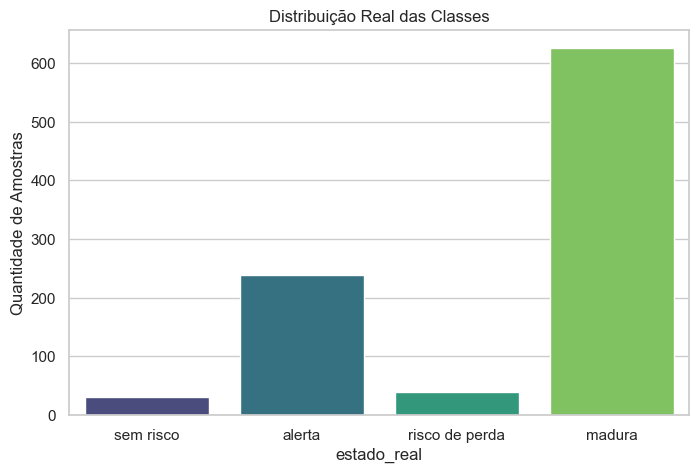

Total de amostras reais: 933
estado_real
madura            625
alerta            238
risco de perda     39
sem risco          31
Name: count, dtype: int64


In [69]:
# Verificando o desequilíbrio real
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Distribuição Real das Classes')
plt.ylabel('Quantidade de Amostras')
plt.show()

print(f"Total de amostras reais: {len(df)}")
print(df['estado_real'].value_counts())

# Otimização com class_weight

In [70]:
# Random Forest configurado para dar peso maior às classes raras
rf_weighted = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train_scaled, y_train)

# Avaliação
y_pred = rf_weighted.predict(X_test_scaled)
print("--- RELATÓRIO DE PERFORMANCE (CLASS WEIGHTS) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- RELATÓRIO DE PERFORMANCE (CLASS WEIGHTS) ---
                precision    recall  f1-score   support

        alerta       0.96      0.96      0.96        48
        madura       0.99      1.00      1.00       125
risco de perda       0.86      0.75      0.80         8
     sem risco       1.00      1.00      1.00         6

      accuracy                           0.98       187
     macro avg       0.95      0.93      0.94       187
  weighted avg       0.98      0.98      0.98       187



# Feature Importance

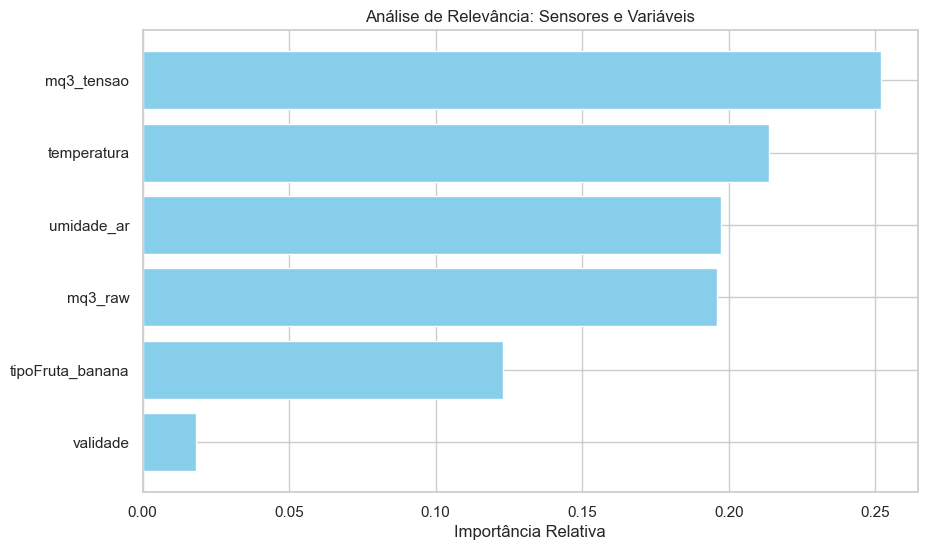

In [71]:
# Treino do Random Forest
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_res, y_res)

# Visualização de Importância das Features
importances = rf_model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances) 

plt.figure(figsize=(10, 6))
plt.title("Análise de Relevância: Sensores e Variáveis")
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Importância Relativa')
plt.show()

# Deployment

In [72]:
# Predição e Relatório
y_pred = rf_model.predict(X_test_scaled)
print("--- RELATÓRIO DE PERFORMANCE ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

joblib.dump(rf_model, 'modelo_frutas_v1.pkl')
joblib.dump(scaler, 'scaler_v1.pkl')
joblib.dump(le, 'label_encoder_v1.pkl')
print("Modelos persistidos em disco.")

--- RELATÓRIO DE PERFORMANCE ---
                precision    recall  f1-score   support

        alerta       1.00      0.96      0.98        48
        madura       0.99      1.00      1.00       125
risco de perda       0.89      1.00      0.94         8
     sem risco       1.00      1.00      1.00         6

      accuracy                           0.99       187
     macro avg       0.97      0.99      0.98       187
  weighted avg       0.99      0.99      0.99       187

Modelos persistidos em disco.


# Análise Exploratória

In [73]:
# Criando subsets para comparação
df_ambiente = df[df['tipoFruta'] == 'ambiente'].copy()
df_frutas = df[df['tipoFruta'] != 'ambiente'].copy()

print(f"Amostras de Ambiente: {len(df_ambiente)}")
print(f"Amostras de Frutas: {len(df_frutas)}")

Amostras de Ambiente: 31
Amostras de Frutas: 902


### Comparação de Assinatura do Sensor (MQ3)

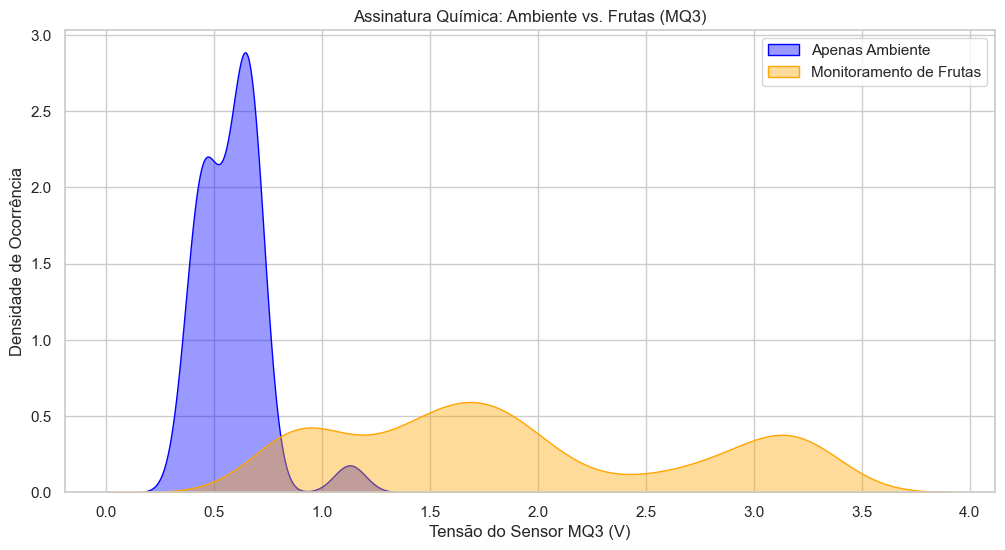

In [74]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_ambiente['mq3_tensao'], label='Apenas Ambiente', fill=True, color='blue', alpha=0.4)
sns.kdeplot(df_frutas['mq3_tensao'], label='Monitoramento de Frutas', fill=True, color='orange', alpha=0.4)

plt.title('Assinatura Química: Ambiente vs. Frutas (MQ3)')
plt.xlabel('Tensão do Sensor MQ3 (V)')
plt.ylabel('Densidade de Ocorrência')
plt.legend()
plt.show()

### Relação Temperatura x Umidade (Ambiente vs Frutas)

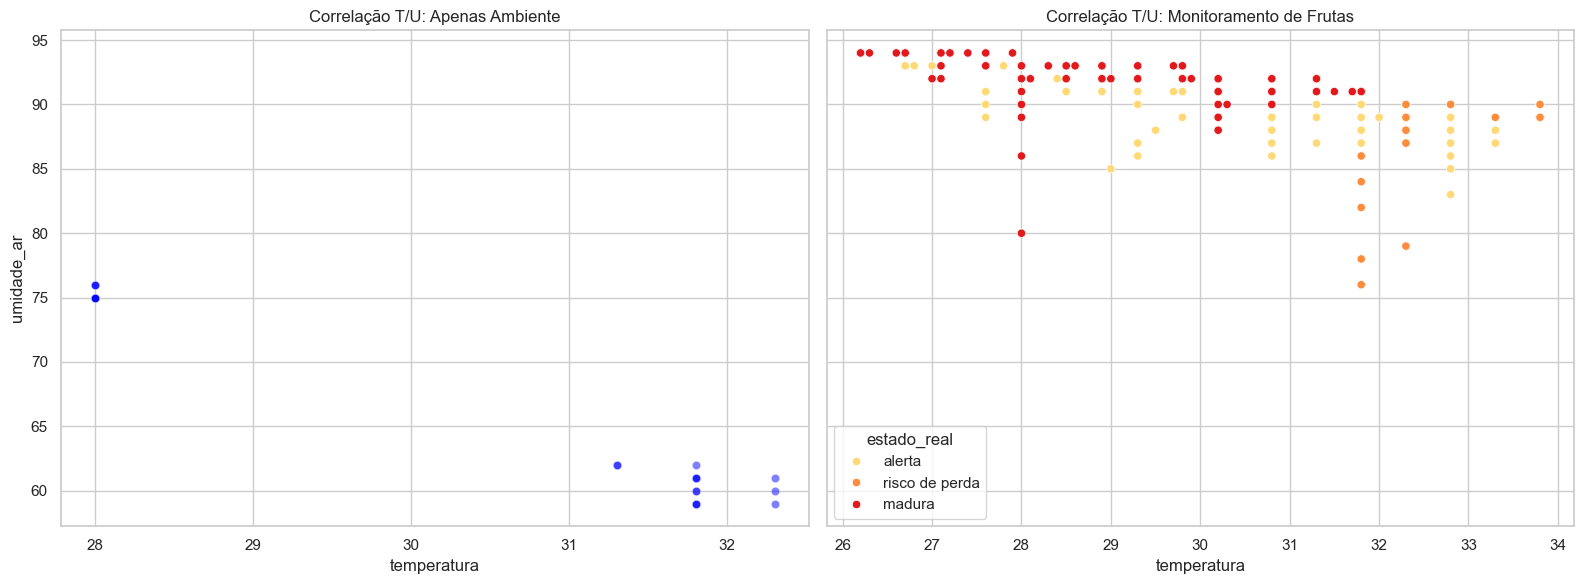

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Gráfico Ambiente
sns.scatterplot(data=df_ambiente, x='temperatura', y='umidade_ar', 
                ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title('Correlação T/U: Apenas Ambiente')

# Gráfico Frutas
sns.scatterplot(data=df_frutas, x='temperatura', y='umidade_ar', 
                hue='estado_real', ax=axes[1], palette='YlOrRd')
axes[1].set_title('Correlação T/U: Monitoramento de Frutas')

plt.tight_layout()
plt.show()

### Boxplot Comparativo por Lote

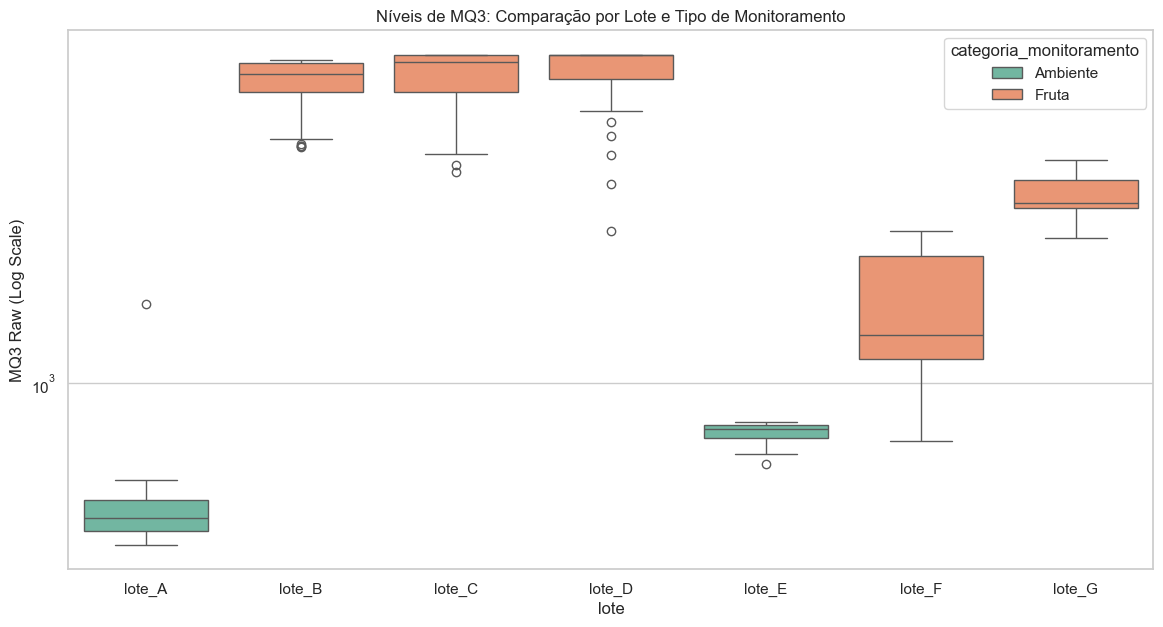

In [76]:
plt.figure(figsize=(14, 7))
# Criamos uma coluna temporária para facilitar a legenda
df['categoria_monitoramento'] = df['tipoFruta'].apply(lambda x: 'Ambiente' if x == 'ambiente' else 'Fruta')

sns.boxplot(data=df, x='lote', y='mq3_raw', hue='categoria_monitoramento', palette='Set2')
plt.title('Níveis de MQ3: Comparação por Lote e Tipo de Monitoramento')
plt.yscale('log') # Escala logarítmica para ver melhor as variações baixas
plt.ylabel('MQ3 Raw (Log Scale)')
plt.show()

## Matriz de Pares - Dispersão por Fruta

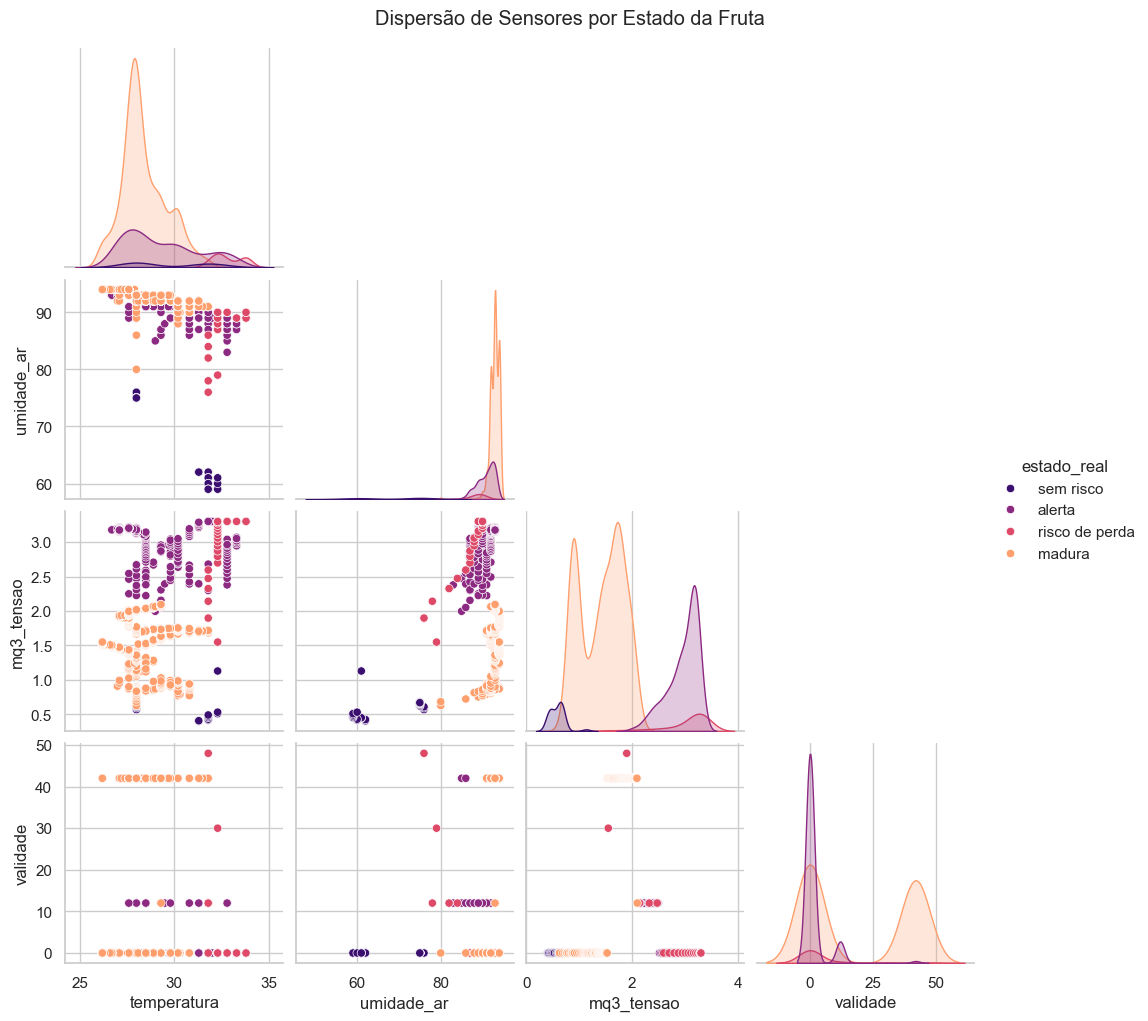

In [77]:
# Selecionando colunas originais do df (antes dos dummies)
cols_num = ['temperatura', 'umidade_ar', 'mq3_tensao', 'validade']
sns.pairplot(df[cols_num + ['tipoFruta', 'estado_real']], 
             hue='estado_real', 
             corner=True, 
             palette='magma')
plt.suptitle('Dispersão de Sensores por Estado da Fruta', y=1.02)
plt.show()

## MQ3 vs Lote e Estado real

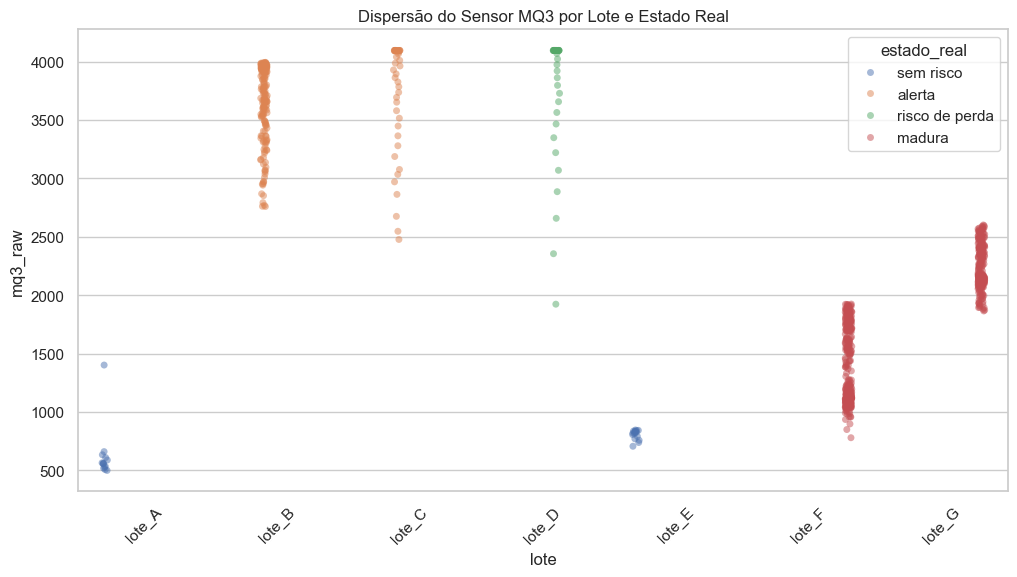

In [81]:
plt.figure(figsize=(12, 6))
# Stripplot para ver a densidade de pontos por lote
sns.stripplot(data=df, x='lote', y='mq3_raw', hue='estado_real', 
              dodge=True, jitter=True, alpha=0.5)
plt.title('Dispersão do Sensor MQ3 por Lote e Estado Real')
plt.xticks(rotation=45)
plt.show()

## Correlação

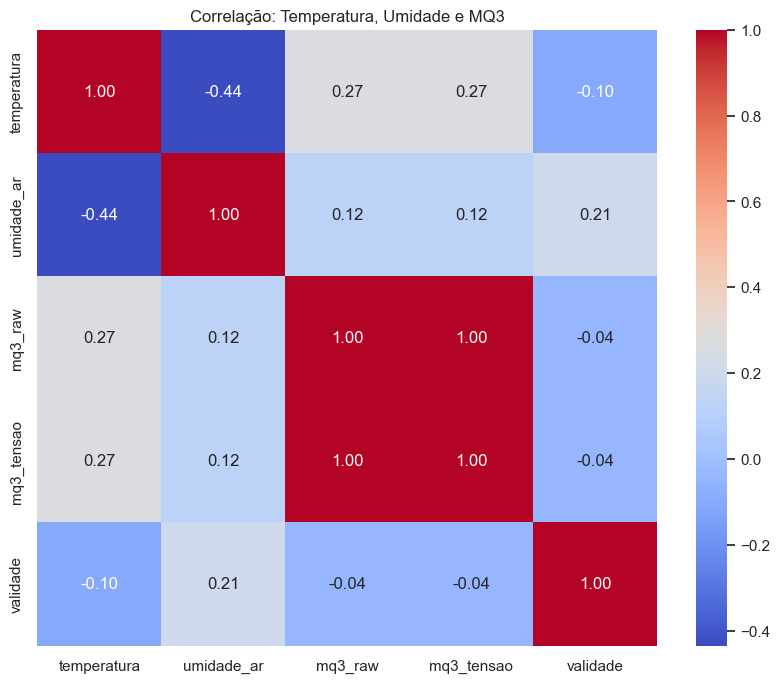

In [82]:
plt.figure(figsize=(10, 8))
# Calculando correlação apenas das numéricas
corr = df[['temperatura', 'umidade_ar', 'mq3_raw', 'mq3_tensao', 'validade']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação: Temperatura, Umidade e MQ3')
plt.show()

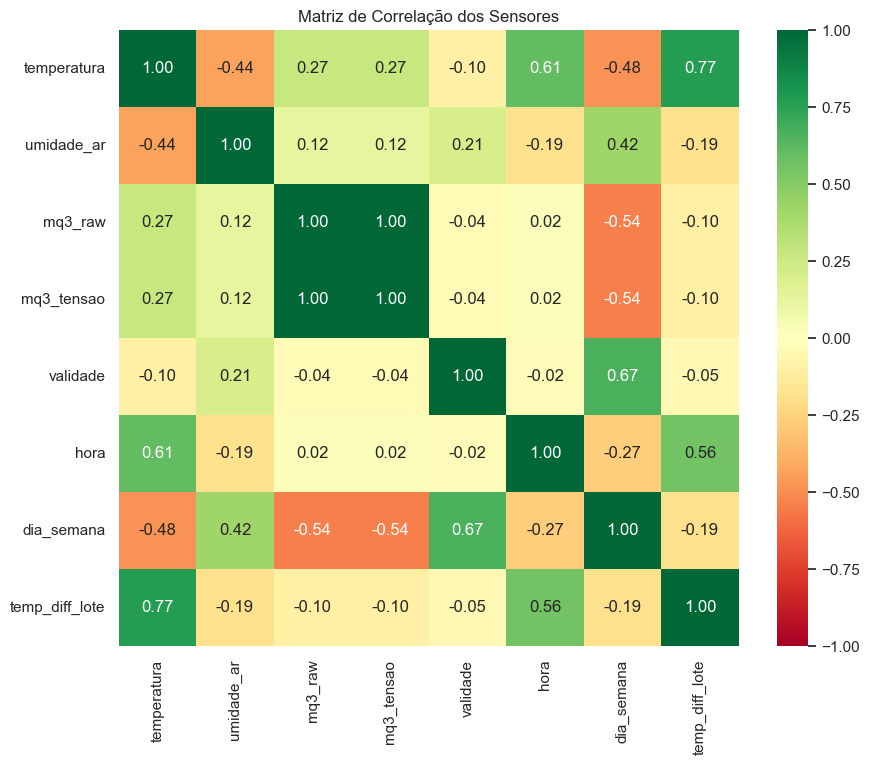

In [83]:
plt.figure(figsize=(10, 8))
# Selecionamos apenas as colunas que são números
df_numeric = df.select_dtypes(include=[np.number])
corr = df_numeric.corr()

sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação dos Sensores')
plt.show()

## Temperatura por Lote e Relação com Estado

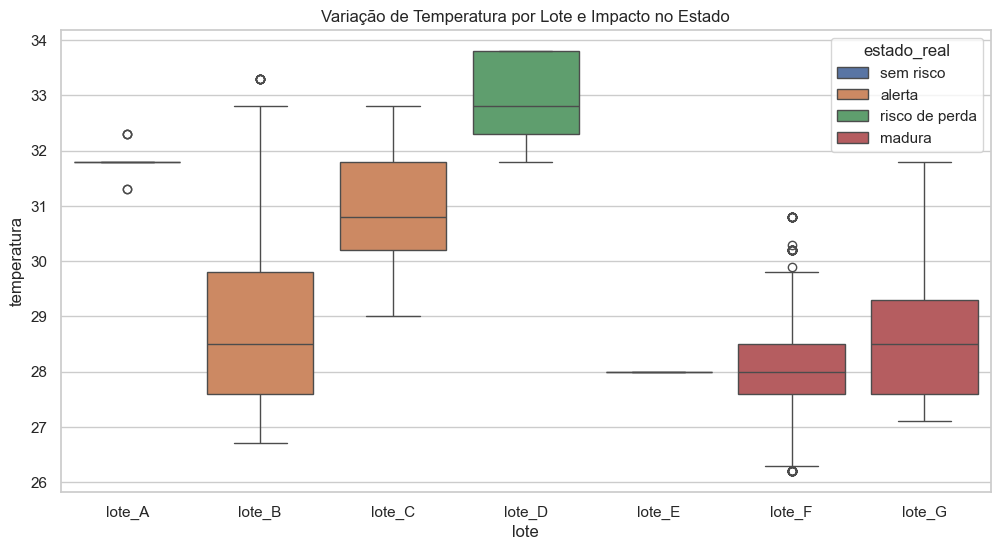

In [84]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='lote', y='temperatura', hue='estado_real')
plt.title('Variação de Temperatura por Lote e Impacto no Estado')
plt.show()

# Exportação

In [85]:
joblib.dump(rf_weighted, 'modelo_frutas_puro_v1.pkl')
joblib.dump(scaler, 'scaler_v1.pkl')
joblib.dump(le, 'label_encoder_v1.pkl')

print("Pipeline finalizado com dados 100% reais.")

Pipeline finalizado com dados 100% reais.


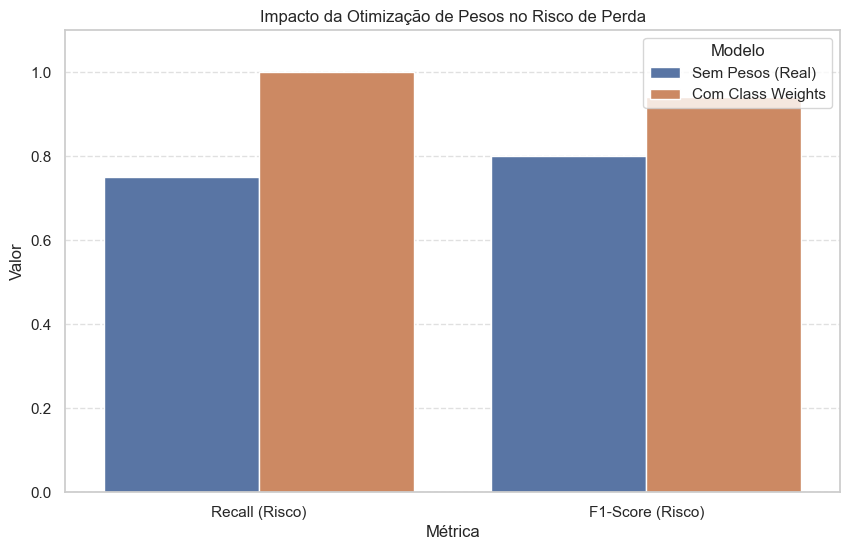

In [86]:
# Dados baseados no seu reporte de performance
data = {
    'Modelo': ['Sem Pesos (Real)', 'Com Class Weights', 'Sem Pesos (Real)', 'Com Class Weights'],
    'Métrica': ['Recall (Risco)', 'Recall (Risco)', 'F1-Score (Risco)', 'F1-Score (Risco)'],
    'Valor': [0.75, 1.00, 0.80, 0.94] 
}

df_comp = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_comp, x='Métrica', y='Valor', hue='Modelo')
plt.ylim(0, 1.1)
plt.title('Impacto da Otimização de Pesos no Risco de Perda')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Comparações de modelos

## Carregamento e Preparação de Benchmark

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Carregar o kit de inferência
scaler = joblib.load('scaler_v1.pkl')
le = joblib.load('label_encoder_v1.pkl')
model_smote = joblib.load('modelo_frutas_v1.pkl')
model_puro = joblib.load('modelo_frutas_puro_v1.pkl')

# Regressão Logística
model_baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
model_baseline.fit(X_train_scaled, y_train)

print("Modelos carregados para comparação.")

Modelos carregados para comparação.


## Cálculo de Métricas Comparativas

In [88]:
def get_metrics(model, X, y_true, name):
    preds = model.predict(X)
    acc = accuracy_score(y_true, preds)
    # 2 é o índice provável de 'risco de perda' no LabelEncoder, ajustamos dinamicamente:
    idx_risco = list(le.classes_).index('risco de perda')
    recall_risco = recall_score(y_true, preds, average=None)[idx_risco]
    f1_geral = f1_score(y_true, preds, average='weighted')
    
    return {'Modelo': name, 'Acurácia': acc, 'Recall (Risco)': recall_risco, 'F1-Score': f1_geral}

# Gerando a tabela de comparação
results = []
results.append(get_metrics(model_smote, X_test_scaled, y_test, "Random Forest + SMOTE"))
results.append(get_metrics(model_puro, X_test_scaled, y_test, "Random Forest + ClassWeights"))
results.append(get_metrics(model_baseline, X_test_scaled, y_test, "Logistic Regression (Baseline)"))

df_bench = pd.DataFrame(results)
display(df_bench)

,Modelo,Acurácia,Recall (Risco),F1-Score
0,Random Forest + SMOTE,0.989305,1.00,0.989359
1,Random Forest + ClassWeights,0.978610,0.75,0.978086
2,Logistic Regression (Baseline),0.951872,1.00,0.956523


## Visualização: O Duelo de Acurácia

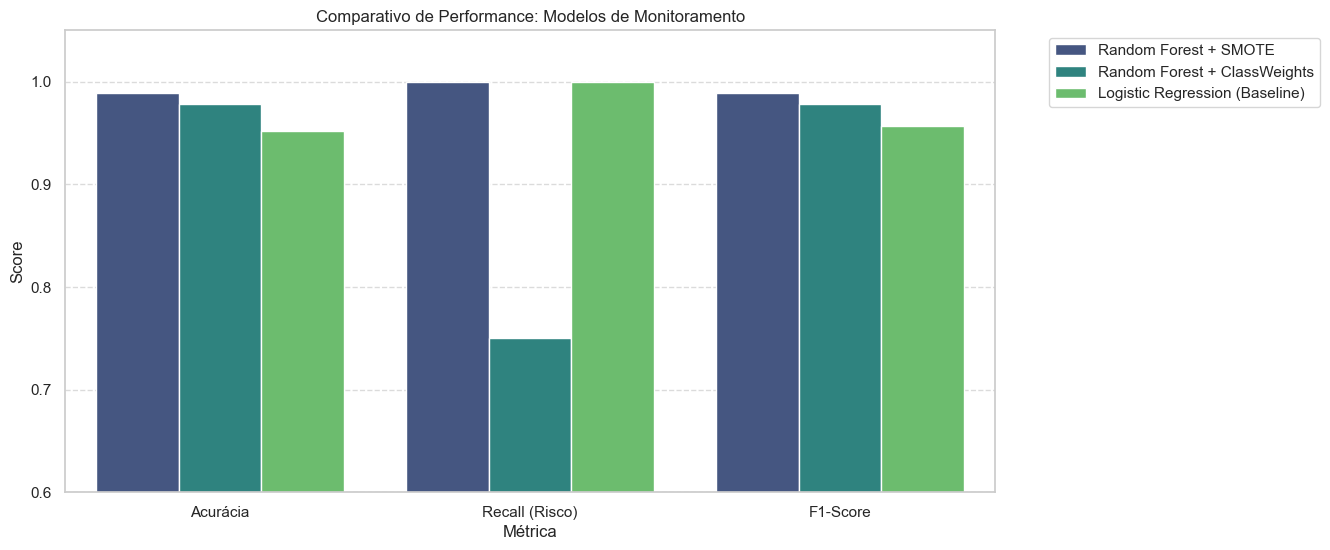

In [89]:
df_plot = df_bench.melt(id_vars='Modelo', var_name='Métrica', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Métrica', y='Score', hue='Modelo', palette='viridis')
plt.title('Comparativo de Performance: Modelos de Monitoramento')
plt.ylim(0.6, 1.05) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Matriz de Confusão Lado a Lado

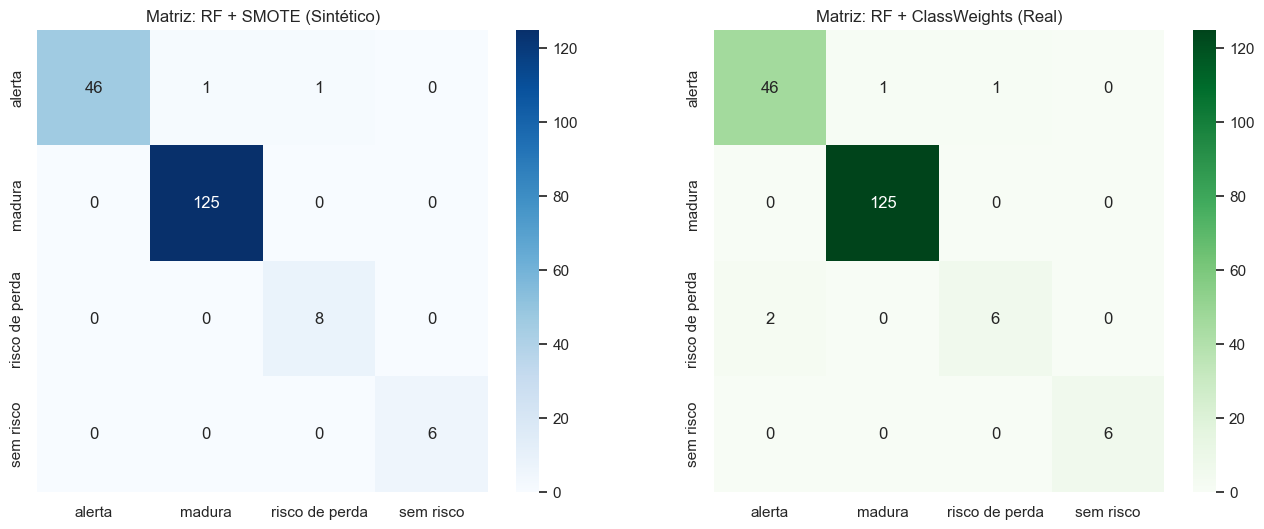

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz Modelo SMOTE
sns.heatmap(confusion_matrix(y_test, model_smote.predict(X_test_scaled)), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Matriz: RF + SMOTE (Sintético)')

# Matriz Modelo Puro
sns.heatmap(confusion_matrix(y_test, model_puro.predict(X_test_scaled)), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Matriz: RF + ClassWeights (Real)')

plt.show()

## Seleção de Atributos: 
### - Informação Mútua (Mutual Information)

C:\Users\Luca\AppData\Local\Temp\ipykernel_19000\3275708507.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette='magma')


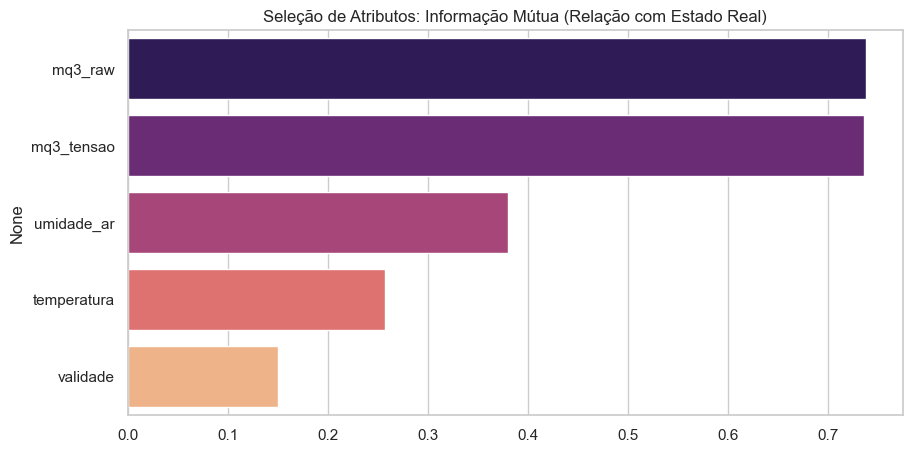

In [91]:
from sklearn.feature_selection import mutual_info_classif

# Calculando MI para as numéricas
X_num = X.select_dtypes(include=[np.number])
mi_scores = mutual_info_classif(X_num, y_encoded, random_state=42)
mi_series = pd.Series(mi_scores, name="MI Scores", index=X_num.columns)
mi_series = mi_series.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='magma')
plt.title("Seleção de Atributos: Informação Mútua (Relação com Estado Real)")
plt.show()

## Seleção do Modelo: 
### - Curva de Aprendizagem (Learning Curve)

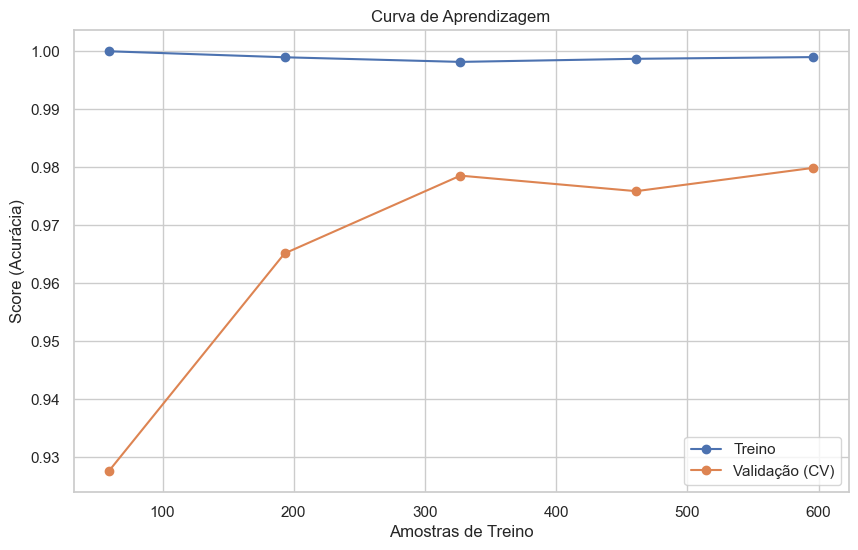

In [93]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(class_weight='balanced', random_state=42), 
    X_train_scaled, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Treino")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Validação (CV)")
plt.title("Curva de Aprendizagem")
plt.xlabel("Amostras de Treino")
plt.ylabel("Score (Acurácia)")
plt.legend()
plt.show()

### Curva de Validação

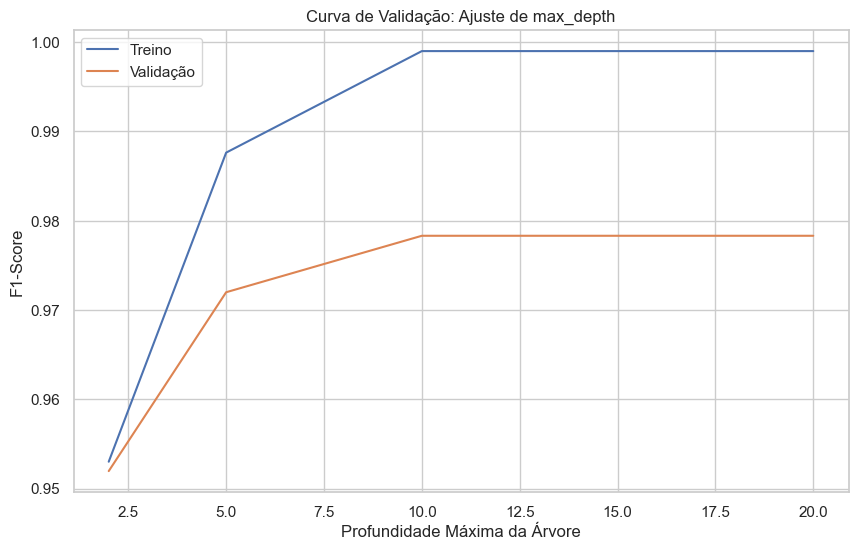

In [96]:
from sklearn.model_selection import validation_curve

param_range = [2, 5, 10, 15, 20]
train_scores, test_scores = validation_curve(
    RandomForestClassifier(class_weight='balanced', random_state=42), 
    X_train_scaled, y_train, 
    param_name="max_depth", 
    param_range=param_range,
    cv=5, scoring="f1_weighted", n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(param_range, np.mean(train_scores, axis=1), label="Treino")
plt.plot(param_range, np.mean(test_scores, axis=1), label="Validação")
plt.title("Curva de Validação: Ajuste de max_depth")
plt.xlabel("Profundidade Máxima da Árvore")
plt.ylabel("F1-Score")
plt.legend()
plt.show()

## Pipeline Completo: 
### - PCA + Classificação

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Criando o Pipeline Profissional
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), # Mantém 95% da variância dos sensores
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipe.fit(X_train, y_train)
y_pred_pipe = pipe.predict(X_test)

print("--- RELATÓRIO DO PIPELINE (COM PCA) ---")
print(classification_report(y_test, y_pred_pipe, target_names=le.classes_))

--- RELATÓRIO DO PIPELINE (COM PCA) ---
                precision    recall  f1-score   support

        alerta       0.96      0.98      0.97        48
        madura       1.00      0.99      1.00       125
risco de perda       0.88      0.88      0.88         8
     sem risco       1.00      1.00      1.00         6

      accuracy                           0.98       187
     macro avg       0.96      0.96      0.96       187
  weighted avg       0.98      0.98      0.98       187



## Interpretabilidade: 
### - Gráfico SHAP (Selection of Attributes)

Analisando: risco de perda


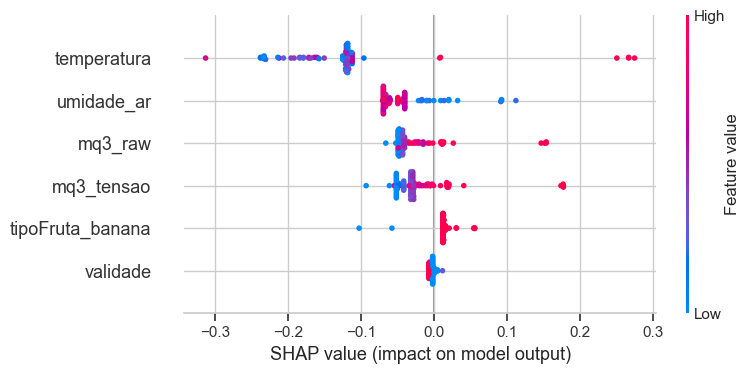

In [99]:
import shap

# DataFrame com os nomes corretos das colunas
X_test_df = pd.DataFrame(X_test_scaled[:100], columns=X.columns)

# Recalcula os valores SHAP (usando o modelo que NÃO passou pelo PCA para manter as colunas originais)
explainer = shap.TreeExplainer(model_puro)
shap_values = explainer.shap_values(X_test_scaled[:100])

# Identificar o índice correto
idx_classe_risco = list(le.classes_).index('risco de perda')

print(f"Analisando: {le.classes_[idx_classe_risco]}")

# Plotar garantindo que SHAP e Dados tenham o mesmo shape
# Se shap_values for uma lista (RandomForest costuma retornar lista no multiclasse)
if isinstance(shap_values, list):
    shap_to_plot = shap_values[idx_classe_risco]
else:
    # Para alguns modelos/versões, o SHAP retorna um array 3D [amostras, features, classes]
    shap_to_plot = shap_values[:, :, idx_classe_risco]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X_test_df)

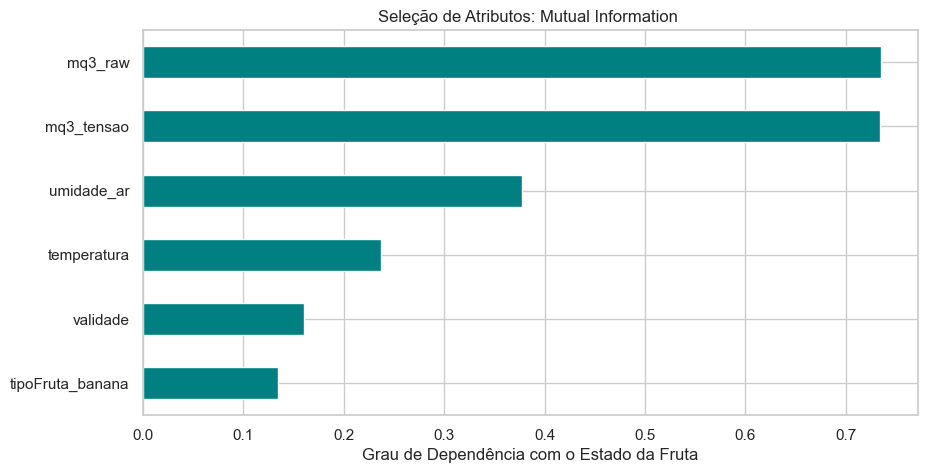

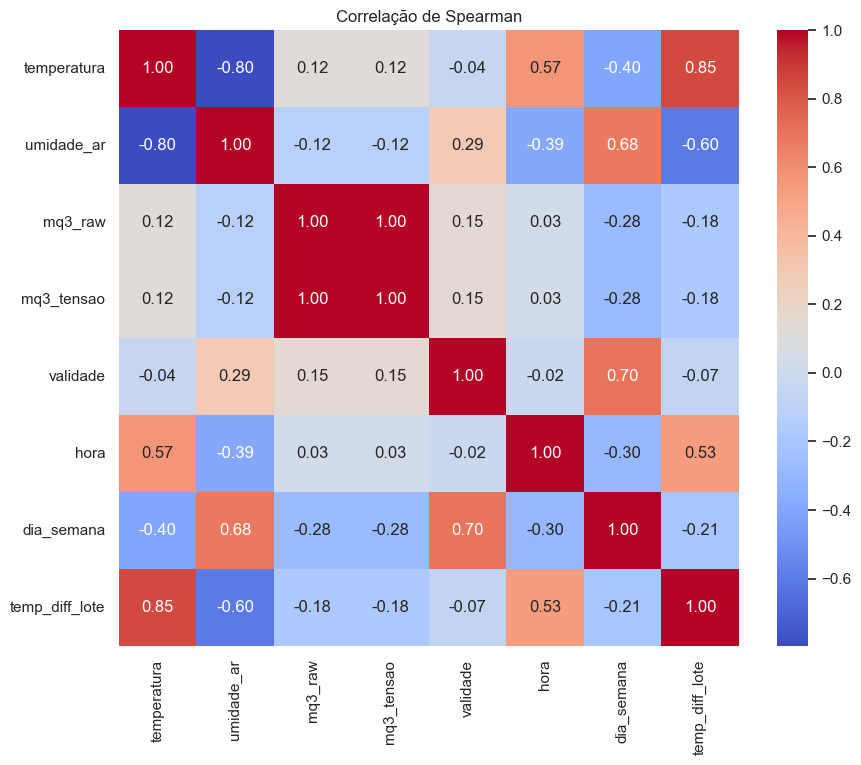

In [101]:
from sklearn.feature_selection import mutual_info_classif

# Informação Mútua (Relações não-lineares)
importâncias_mi = mutual_info_classif(X, y_encoded)
mi_df = pd.Series(importâncias_mi, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
mi_df.plot(kind='barh', color='teal')
plt.title("Seleção de Atributos: Mutual Information ")
plt.xlabel("Grau de Dependência com o Estado da Fruta")
plt.show()

# Correlação de Spearman (Captura tendências de sensores)
plt.figure(figsize=(10, 8))
corr_spearman = df.select_dtypes(include=[np.number]).corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação de Spearman")
plt.show()

## Curva ROC Multiclasse

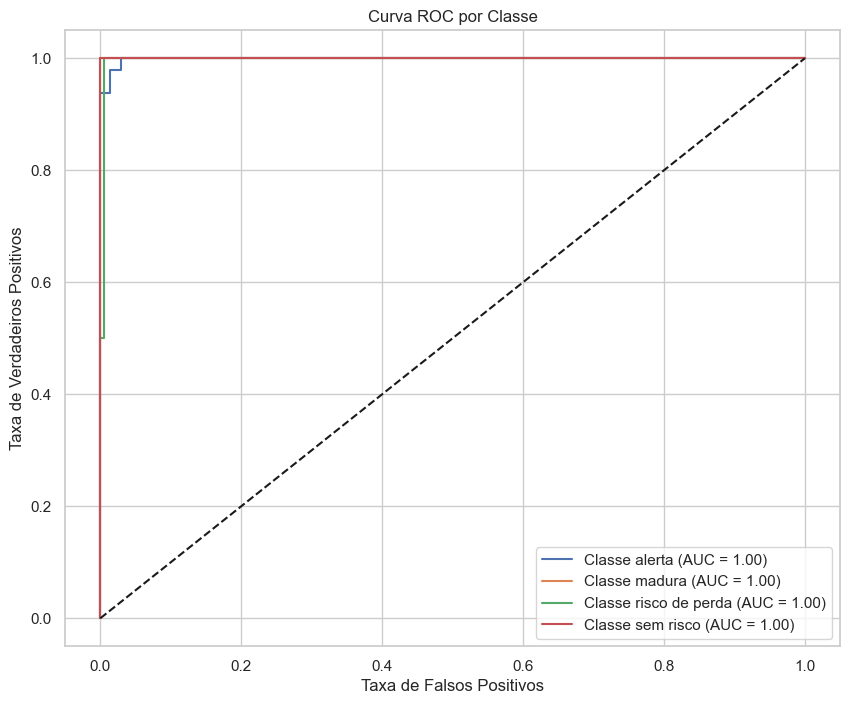

In [102]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar o alvo para o gráfico
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_score = model_puro.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Classe {le.classes_[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC por Classe')
plt.legend()
plt.show()

In [103]:
# Salvando o objeto Pipeline 
joblib.dump(pipe, 'pipeline_frutas_final.pkl')

print("Pipeline Profissional exportado.")
print("Checklist de Capítulos Concluído:")
print("- [x] Engenharia de Datas\n- [x] PCA e Redução de Dimensionalidade\n- [x] Curvas de Aprendizagem e Validação\n- [x] SHAP e Seleção de Atributos")

Pipeline Profissional exportado.
Checklist de Capítulos Concluído:
- [x] Engenharia de Datas
- [x] PCA e Redução de Dimensionalidade
- [x] Curvas de Aprendizagem e Validação
- [x] SHAP e Seleção de Atributos
